In [45]:
import os
import csv
import pandas as pd
import numpy as  np
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.preprocessing import  StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score


In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


step 1 read data

In [47]:
match_data=pd.read_csv('/content/drive/MyDrive/Machine learning files/datasets/match_predictions.csv')
match_data.head()

,snapshot_date,kickoff_date,kickoff_utc,stage,fixture_type,home_team,away_team,prob_meeting,prob_home_win,prob_draw,prob_away_win,exp_home_goals,exp_away_goals
0,2026-06-28,2026-06-28,2026-06-28T19:00Z,Round of 32,knockout,South Africa,Canada,1.0,0.2984,0.2848,0.4168,1.121,1.466
1,2026-06-28,2026-06-29,2026-06-29T17:00Z,Round of 32,knockout,Brazil,Japan,1.0,0.4919,0.2607,0.2474,1.505,1.123
2,2026-06-28,2026-06-29,2026-06-29T20:30Z,Round of 32,knockout,Germany,Paraguay,1.0,0.5514,0.2522,0.1964,2.050,0.996
3,2026-06-28,2026-06-30,2026-06-30T01:00Z,Round of 32,knockout,Netherlands,Morocco,1.0,0.4244,0.2790,0.2966,1.291,1.252
4,2026-06-28,2026-06-30,2026-06-30T17:00Z,Round of 32,knockout,Ivory Coast,Norway,1.0,0.3351,0.2284,0.4365,1.248,1.464


step 2 clean data

In [48]:
match_data=match_data.drop('snapshot_date',axis=1)
match_data=match_data.drop('kickoff_date',axis=1)
match_data=match_data.drop('stage',axis=1)
match_data=match_data.drop('fixture_type',axis=1)
match_data.head()

,kickoff_utc,home_team,away_team,prob_meeting,prob_home_win,prob_draw,prob_away_win,exp_home_goals,exp_away_goals
0,2026-06-28T19:00Z,South Africa,Canada,1.0,0.2984,0.2848,0.4168,1.121,1.466
1,2026-06-29T17:00Z,Brazil,Japan,1.0,0.4919,0.2607,0.2474,1.505,1.123
2,2026-06-29T20:30Z,Germany,Paraguay,1.0,0.5514,0.2522,0.1964,2.050,0.996
3,2026-06-30T01:00Z,Netherlands,Morocco,1.0,0.4244,0.2790,0.2966,1.291,1.252
4,2026-06-30T17:00Z,Ivory Coast,Norway,1.0,0.3351,0.2284,0.4365,1.248,1.464


In [49]:

match_data['kickoff_utc']=pd.to_datetime(match_data['kickoff_utc'])
match_data['match_day']=match_data['kickoff_utc'].dt.day
match_data['time']=match_data['kickoff_utc'].dt.hour
match_data.head()

,kickoff_utc,home_team,away_team,prob_meeting,prob_home_win,prob_draw,prob_away_win,exp_home_goals,exp_away_goals,match_day,time
0,2026-06-28 19:00:00+00:00,South Africa,Canada,1.0,0.2984,0.2848,0.4168,1.121,1.466,28,19
1,2026-06-29 17:00:00+00:00,Brazil,Japan,1.0,0.4919,0.2607,0.2474,1.505,1.123,29,17
2,2026-06-29 20:30:00+00:00,Germany,Paraguay,1.0,0.5514,0.2522,0.1964,2.050,0.996,29,20
3,2026-06-30 01:00:00+00:00,Netherlands,Morocco,1.0,0.4244,0.2790,0.2966,1.291,1.252,30,1
4,2026-06-30 17:00:00+00:00,Ivory Coast,Norway,1.0,0.3351,0.2284,0.4365,1.248,1.464,30,17


In [50]:
match_data=match_data.drop('kickoff_utc',axis=1)
match_data.head()

,home_team,away_team,prob_meeting,prob_home_win,prob_draw,prob_away_win,exp_home_goals,exp_away_goals,match_day,time
0,South Africa,Canada,1.0,0.2984,0.2848,0.4168,1.121,1.466,28,19
1,Brazil,Japan,1.0,0.4919,0.2607,0.2474,1.505,1.123,29,17
2,Germany,Paraguay,1.0,0.5514,0.2522,0.1964,2.050,0.996,29,20
3,Netherlands,Morocco,1.0,0.4244,0.2790,0.2966,1.291,1.252,30,1
4,Ivory Coast,Norway,1.0,0.3351,0.2284,0.4365,1.248,1.464,30,17


In [51]:
match_data=pd.get_dummies(match_data,columns=['home_team','away_team'])
match_data.head()

,prob_meeting,prob_home_win,prob_draw,prob_away_win,exp_home_goals,exp_away_goals,match_day,time,home_team_Argentina,home_team_Australia,...,away_team_Croatia,away_team_Ecuador,away_team_Egypt,away_team_Ghana,away_team_Japan,away_team_Morocco,away_team_Norway,away_team_Paraguay,away_team_Senegal,away_team_Sweden
0,1.0,0.2984,0.2848,0.4168,1.121,1.466,28,19,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1.0,0.4919,0.2607,0.2474,1.505,1.123,29,17,False,False,...,False,False,False,False,True,False,False,False,False,False
2,1.0,0.5514,0.2522,0.1964,2.050,0.996,29,20,False,False,...,False,False,False,False,False,False,False,True,False,False
3,1.0,0.4244,0.2790,0.2966,1.291,1.252,30,1,False,False,...,False,False,False,False,False,True,False,False,False,False
4,1.0,0.3351,0.2284,0.4365,1.248,1.464,30,17,False,False,...,False,False,False,False,False,False,True,False,False,False


step 3 create variables for features and labels

In [52]:
y=match_data.iloc[:,3]


In [53]:
match_data=match_data.drop('prob_away_win',axis=1)
match_data.head()

,prob_meeting,prob_home_win,prob_draw,exp_home_goals,exp_away_goals,match_day,time,home_team_Argentina,home_team_Australia,home_team_Belgium,...,away_team_Croatia,away_team_Ecuador,away_team_Egypt,away_team_Ghana,away_team_Japan,away_team_Morocco,away_team_Norway,away_team_Paraguay,away_team_Senegal,away_team_Sweden
0,1.0,0.2984,0.2848,1.121,1.466,28,19,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1.0,0.4919,0.2607,1.505,1.123,29,17,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,1.0,0.5514,0.2522,2.050,0.996,29,20,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,1.0,0.4244,0.2790,1.291,1.252,30,1,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,1.0,0.3351,0.2284,1.248,1.464,30,17,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [54]:
x=match_data.iloc[:,0:]

step 4 visualize data after cleaning

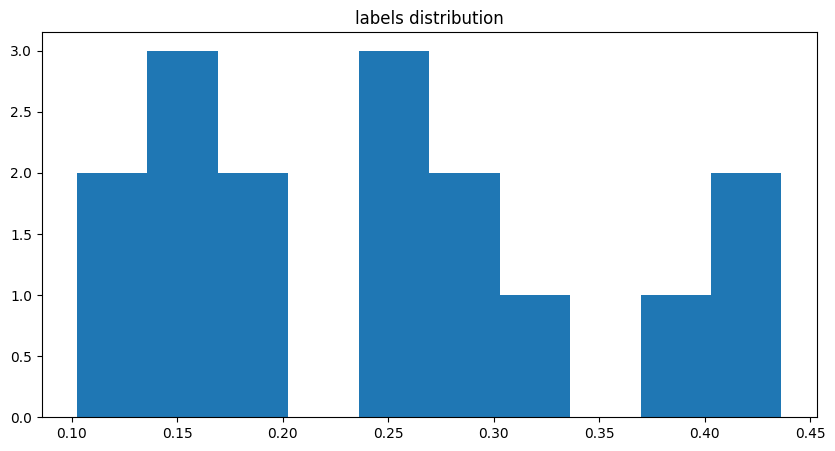

In [55]:
fig=plt.figure(figsize=(10,5))
plt.hist(y)
plt.title('labels distribution')
plt.show()


step 5 split data for training

In [56]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)


step 6 scale data

In [57]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
x_unsplited=scaler.transform(x)

STEP 7 model training and hyper parameter tunning

In [58]:
model1=RandomForestRegressor(n_estimators=100,max_depth=3)
model1.fit(x_train_scaled,y_train)

RandomForestRegressor(max_depth=3)

In [59]:
model1.score(x_train_scaled,y_train)

0.9586783075722057

In [60]:
model1_predictions=model1.predict(x_test_scaled)

In [61]:
model1.score(x_test_scaled,y_test)

0.5168615325346674

In [62]:
accurate_score=cross_val_score(model1,x_unsplited,y,cv=5)
accurate_score.mean()

np.float64(0.6885393446758072)

In [63]:
model2=GradientBoostingRegressor(n_estimators=100)
model2.fit(x_train_scaled,y_train)

GradientBoostingRegressor()

In [64]:
model2.score(x_train_scaled,y_train)

0.999999999081362

In [65]:
model2_predictions=model2.predict(x_test_scaled)

In [66]:
model2.score(x_test_scaled,y_test)

-0.22113923591030304

In [67]:
accurate_score2=cross_val_score(model2,x_unsplited,y,cv=5)
accurate_score2.mean()

np.float64(0.5642965673550113)

random forest gave me a better score i can then save the model using joblib